In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [148]:
df=pd.read_csv('IDTA.csv')
df.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Gender                                 2054 non-null   object
 1   Age                                    2054 non-null   int64 
 2   Work Pressure                          2054 non-null   int64 
 3   Job Satisfaction                       2054 non-null   int64 
 4   Sleep Duration                         2054 non-null   object
 5   Dietary Habits                         2054 non-null   object
 6   Have you ever had suicidal thoughts ?  2054 non-null   object
 7   Work Hours                             2054 non-null   int64 
 8   Financial Stress                       2054 non-null   int64 
 9   Family History of Mental Illness       2054 non-null   object
 10  Depression                             2054 non-null   object
dtypes: int64(5), obje

In [150]:
df.shape

(2054, 11)

In [151]:
df.isnull().sum()

Gender                                   0
Age                                      0
Work Pressure                            0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work Hours                               0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [152]:
df_num = df.select_dtypes(include=np.number).columns
df_cat = df.select_dtypes(include='object').columns
print("Numerical columns:")
print(df_num)
print("-------------------")
print("Categorical columns:")
print(df_cat)


Numerical columns:
Index(['Age', 'Work Pressure', 'Job Satisfaction', 'Work Hours',
       'Financial Stress'],
      dtype='object')
-------------------
Categorical columns:
Index(['Gender', 'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [153]:
df['Sleep Duration'] = df['Sleep Duration'].replace({'7-8 hours':7.5, '5-6 hours':5.5, 'More than 8 hours':9, 'Less than 5 hours':4})
df['Dietary Habits'] = df['Dietary Habits'].replace({'Healthy':2, 'Moderate':1, 'Unhealthy':0})
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].replace({'Yes':1, 'No':0})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].replace({'Yes':1, 'No':0})
df['Depression'] = df['Depression'].replace({'Yes':1, 'No':0})
df['Gender']=df['Gender'].replace({'Female':0,'Male':1})

/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/958675764.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sleep Duration'] = df['Sleep Duration'].replace({'7-8 hours':7.5, '5-6 hours':5.5, 'More than 8 hours':9, 'Less than 5 hours':4})
/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/958675764.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Dietary Habits'] = df['Dietary Habits'].replace({'Healthy':2, 'Moderate':1, 'Unhealthy':0})
/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipyke

In [154]:
df[df_num].describe()

,Age,Work Pressure,Job Satisfaction,Work Hours,Financial Stress
count,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000
mean,42.171860,3.021908,3.015093,5.930867,2.978578
std,11.461202,1.417312,1.418432,3.773945,1.413362
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,35.000000,2.000000,2.000000,3.000000,2.000000
50%,43.000000,3.000000,3.000000,6.000000,3.000000
75%,51.750000,4.000000,4.000000,9.000000,4.000000
max,60.000000,5.000000,5.000000,12.000000,5.000000


In [168]:
for col in range(len(df_cat)):
    print(df[df_cat[col]].value_counts())
    print('_' * 40)


Gender
1    1066
0     988
Name: count, dtype: int64
________________________________________
Sleep Duration
7.5    530
4.0    525
5.5    505
9.0    494
Name: count, dtype: int64
________________________________________
Dietary Habits
0    713
2    681
1    660
Name: count, dtype: int64
________________________________________
Have you ever had suicidal thoughts ?
0    1065
1     989
Name: count, dtype: int64
________________________________________
Family History of Mental Illness
0    1046
1    1008
Name: count, dtype: int64
________________________________________
Depression
0    1851
1     203
Name: count, dtype: int64
________________________________________


/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/884205634.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(data=df, x='Gender', hue='Depression', palette=colors)


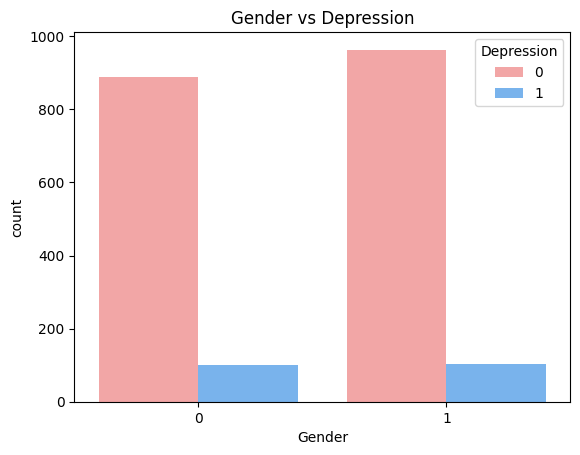

In [156]:
sns.countplot(data=df, x='Gender', hue='Depression', palette=colors)
plt.title('Gender vs Depression')
plt.show()

/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/3724955275.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(data=df, x='Sleep Duration',hue='Depression',palette=colors)


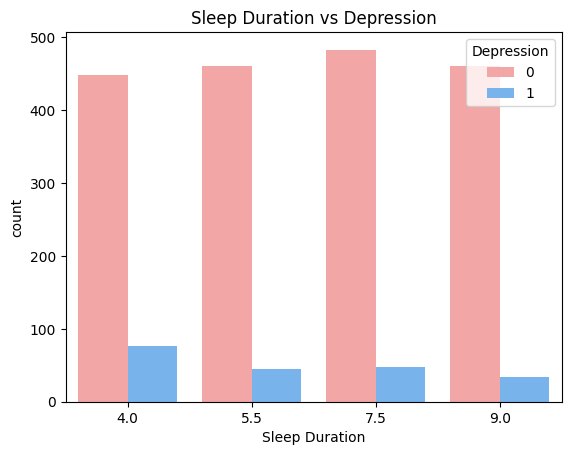

In [157]:
sns.countplot(data=df, x='Sleep Duration',hue='Depression',palette=colors)
plt.title('Sleep Duration vs Depression')
plt.show()

/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/3180953466.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.histplot(df, x="Age", hue="Have you ever had suicidal thoughts ?", multiple="dodge", kde=True, palette=colors)


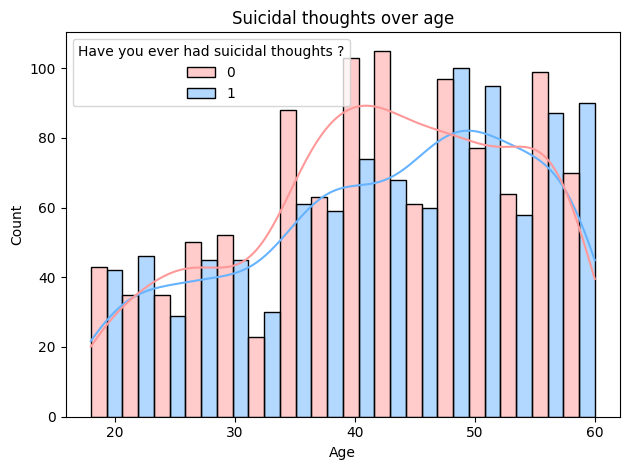

In [158]:
sns.histplot(df, x="Age", hue="Have you ever had suicidal thoughts ?", multiple="dodge", kde=True, palette=colors)
plt.title("Suicidal thoughts over age")
plt.tight_layout()
plt.show()

/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_4482/2751270497.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.histplot(df, x="Age", hue="Depression", multiple="dodge", kde=True,palette=colors   )


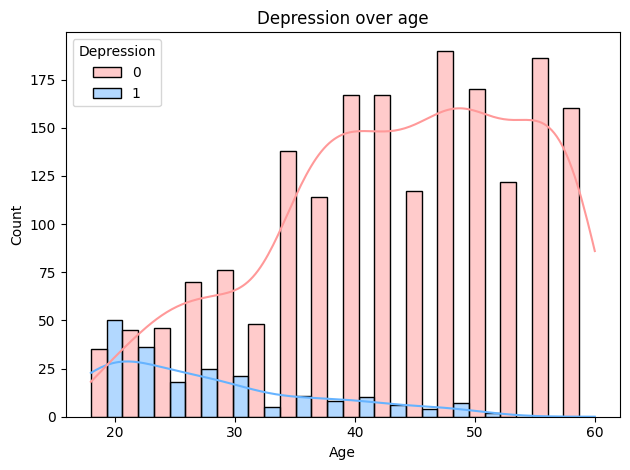

In [159]:
sns.histplot(df, x="Age", hue="Depression", multiple="dodge", kde=True,palette=colors   )
plt.title("Depression over age")
plt.tight_layout()
plt.show()

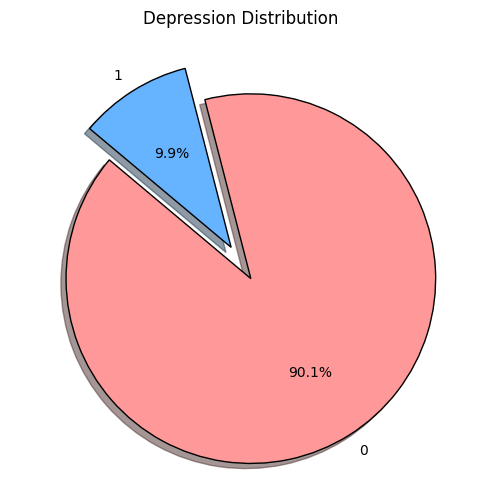

In [160]:
depression_counts = df['Depression'].value_counts()

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.figure(figsize=(6, 6))
plt.pie(depression_counts, 
        labels=depression_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        shadow=True, 
        explode=[0.1] * len(depression_counts),  
        wedgeprops={'edgecolor': 'black'})  

plt.title('Depression Distribution')

plt.show()

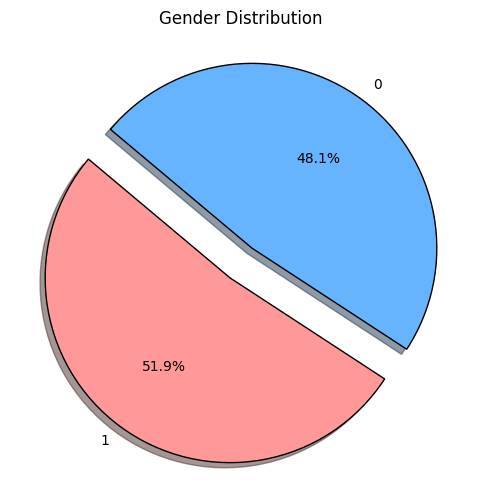

In [161]:
Gender_counts = df['Gender'].value_counts()

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.figure(figsize=(6, 6))
plt.pie(Gender_counts, 
        labels=Gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        shadow=True, 
        explode=[0.1] * len(Gender_counts),  
        wedgeprops={'edgecolor': 'black'})  

plt.title('Gender Distribution')

plt.show()

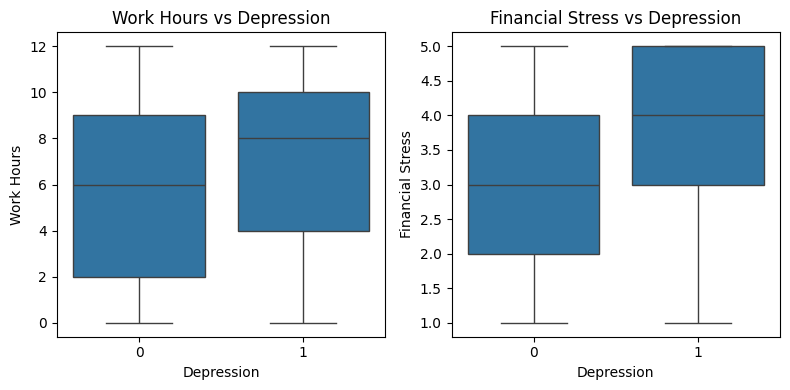

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.boxplot(data=df, x="Depression", y="Work Hours", ax=axes[0])
axes[0].set_title('Work Hours vs Depression')

sns.boxplot(data=df, x="Depression", y="Financial Stress", ax=axes[1])
axes[1].set_title('Financial Stress vs Depression')

plt.tight_layout()
plt.show()

In [163]:
df['Sleep Duration'].unique()



array([7.5, 5.5, 9. , 4. ])

In [164]:
df['Dietary Habits'].unique()

array([1, 0, 2])

In [165]:
numerical_cols = df.columns
print(numerical_cols)

Index(['Gender', 'Age', 'Work Pressure', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


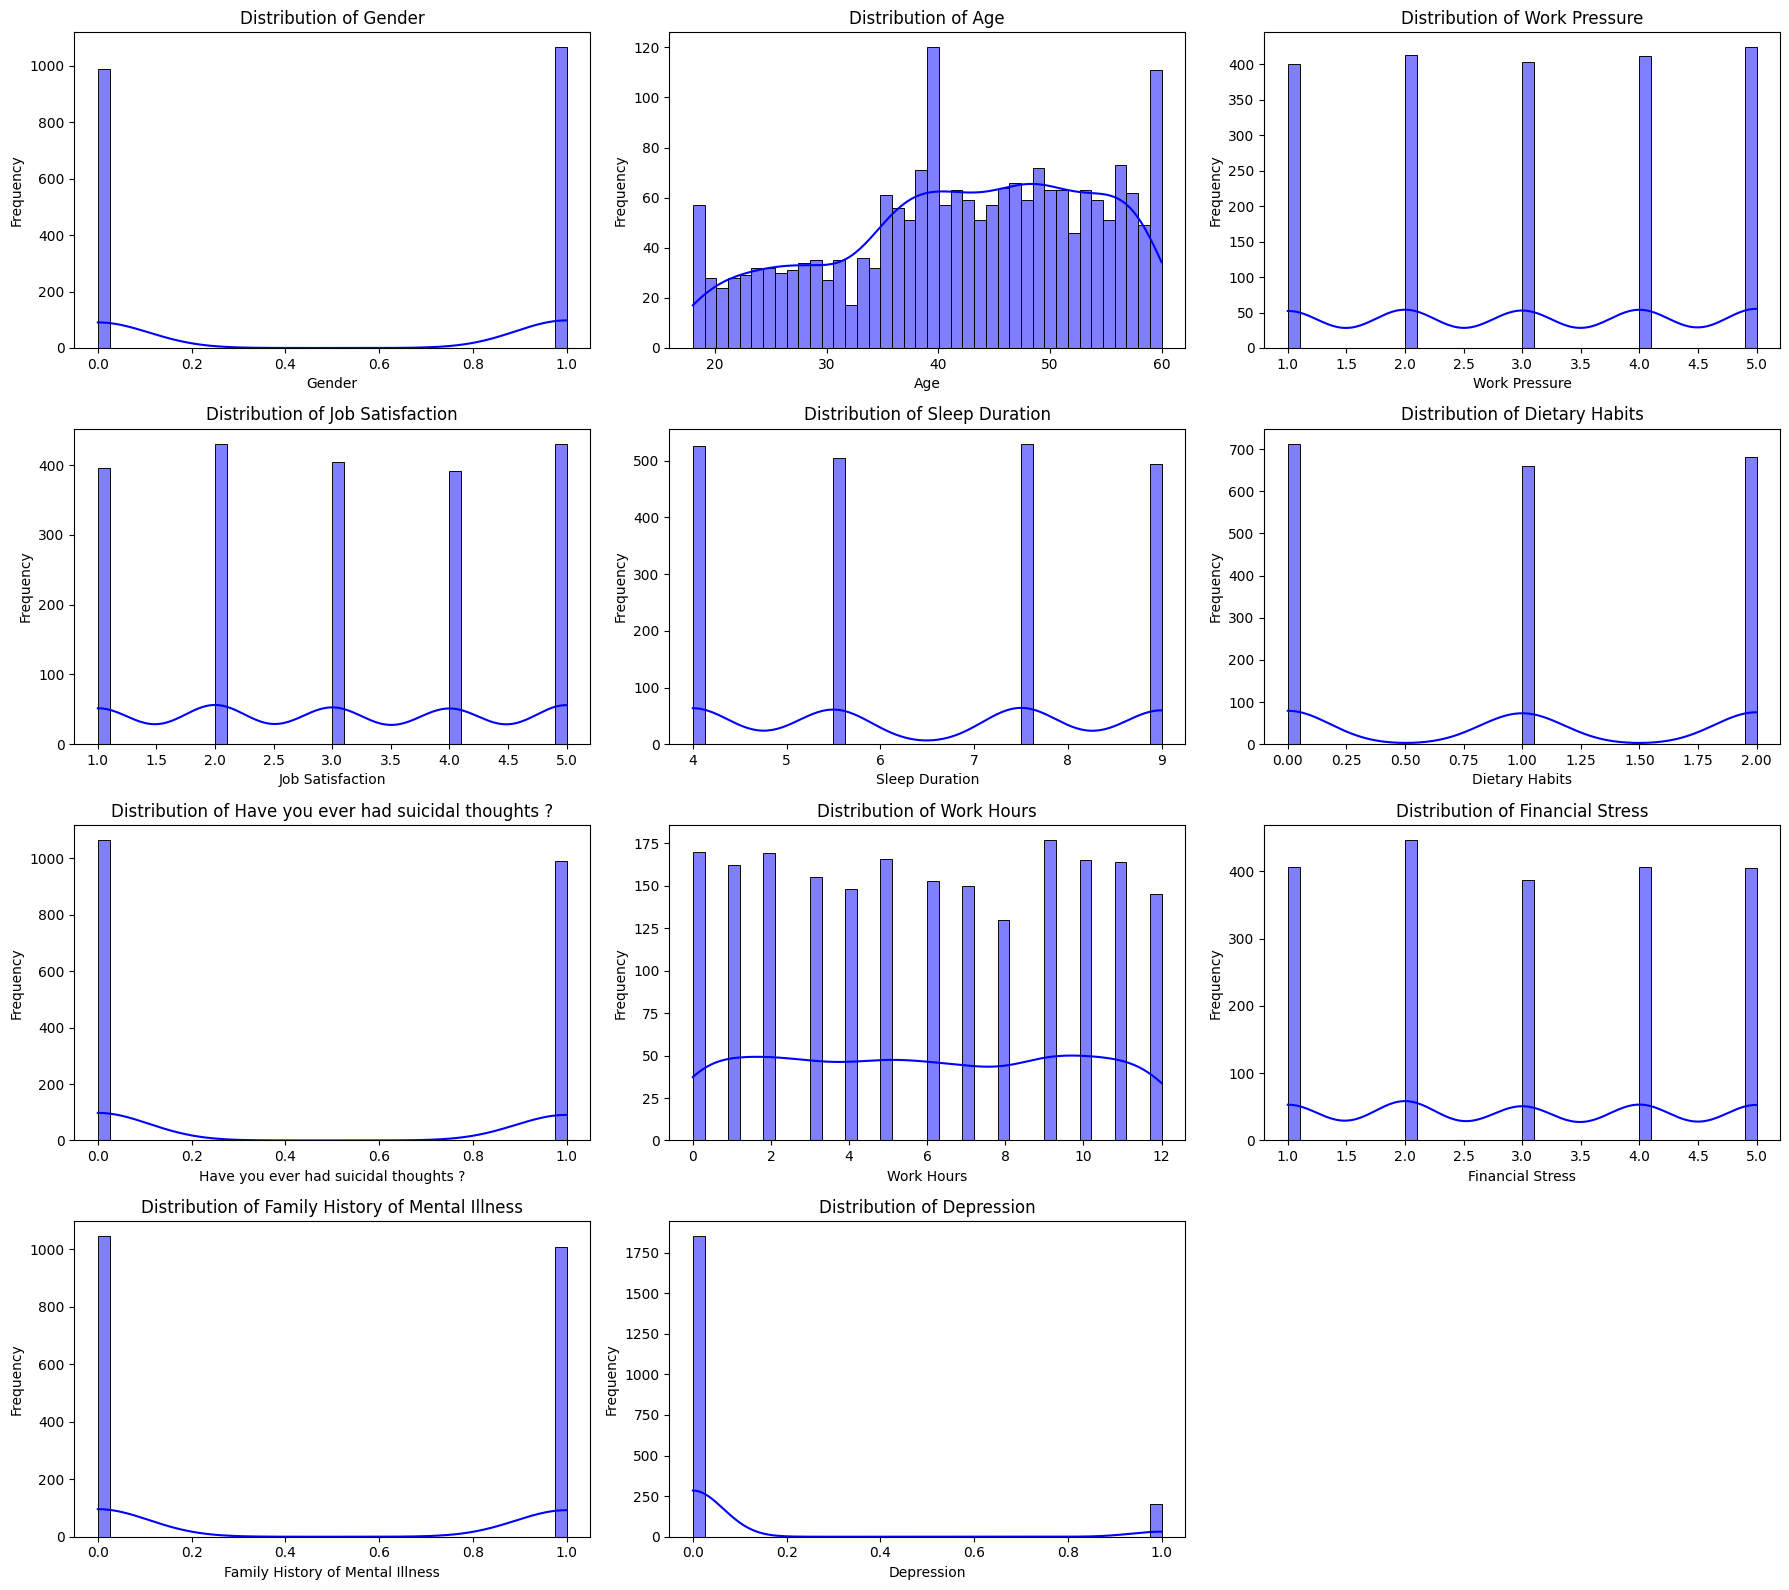

In [166]:

num_cols = len(numerical_cols)
fig, axes = plt.subplots(nrows=(num_cols + 2) // 3, ncols=3, figsize=(18, 4 * ((num_cols + 2) // 3)))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, color='blue', bins=40, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

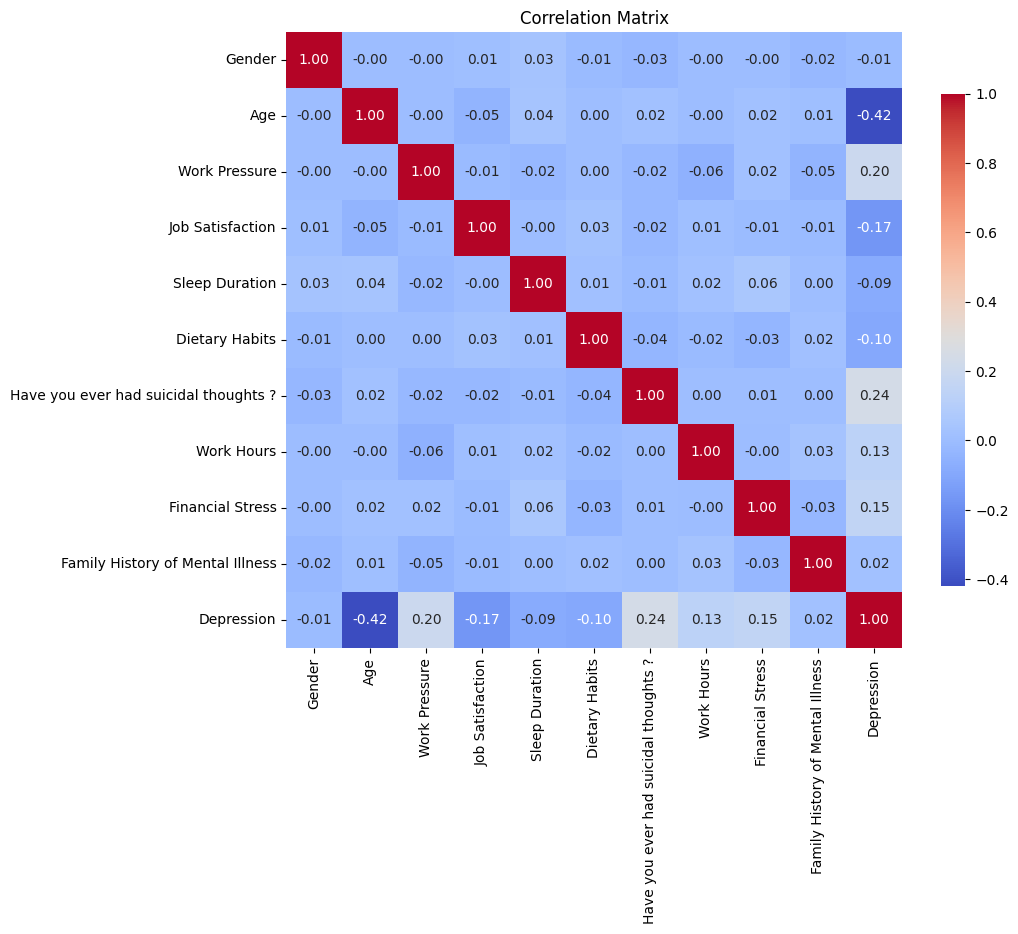

In [ ]:

corr = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()
